# LLM User Story Quality Evaluation - Analysis Notebook

This notebook analyzes the results of evaluating user story quality using GPT models and the QUS Framework.

## Contents
1. Load and Explore Data
2. Defect Distribution Analysis
3. Model Comparison
4. Performance Metrics
5. Visualizations

In [15]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Explore Data

In [16]:
# Load processed data
df = pd.read_excel('../data/processed/data_processed.xlsx')

print(f"Total evaluations: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nModels: {df['model'].unique()}")
print(f"\nAverage processing time: {df['time'].mean():.2f}s")

df.head()

Total evaluations: 9

Columns: ['user_story', 'model', 'prompt', 'response', 'time']

Models: ['gpt-5-mini' 'gpt-4' 'gpt-5']

Average processing time: 120.26s


,user_story,model,prompt,response,time
0,"As a anonymoususer, I want to view a list of s...",gpt-5-mini,System: You will serve as a quality analyzer f...,"{\n ""defects"": [\n {\n ""story_id"": 3,...",120.254446
1,"As a anonymoususer, I want to view a list of s...",gpt-4,System: You will serve as a quality analyzer f...,"{\n ""defects"": [\n {\n ""story_id"": 5,...",11.563136
2,"As a anonymoususer, I want to view a list of s...",gpt-5,System: You will serve as a quality analyzer f...,"{\n ""defects"": [\n {\n ""story_id"": 1,...",295.684424
3,"As a moderator, I want to create a new game by...",gpt-5-mini,System: You will serve as a quality analyzer f...,"{\n ""defects"": [\n {\n ""story_id"": 6,...",101.428154
4,"As a moderator, I want to create a new game by...",gpt-4,System: You will serve as a quality analyzer f...,"{\n ""defects"": [\n {\n ""story_id"": 27...",11.581146


## 2. Defect Distribution Analysis

In [17]:
# Parse all responses and aggregate defects
all_defects = defaultdict(int)
total_stories = 0
total_defects = 0

for idx, row in df.iterrows():
    response = json.loads(row['response'])
    total_stories += response['summary']['total_stories']
    total_defects += response['summary']['total_defects']
    
    for defect_type, count in response['summary']['defect_types_count'].items():
        all_defects[defect_type] += count

print(f"Total stories analyzed: {total_stories}")
print(f"Total defects found: {total_defects}")
print(f"Average defects per story: {total_defects / total_stories:.2f}")
print(f"\nDefect distribution:")

sorted_defects = sorted(all_defects.items(), key=lambda x: x[1], reverse=True)
for defect_type, count in sorted_defects:
    percentage = (count / total_defects) * 100
    print(f"  {defect_type:30s}: {count:3d} ({percentage:5.1f}%)")

Total stories analyzed: 547
Total defects found: 193
Average defects per story: 0.35

Defect distribution:
  uniform.uniform               : 118 ( 61.1%)
  atomic.conjunctions           :  45 ( 23.3%)
  minimal.punctuation           :  23 ( 11.9%)
  minimal.brackets              :   3 (  1.6%)
  well_formed.no_means          :   2 (  1.0%)
  well_formed.no_role           :   1 (  0.5%)
  unique.identical              :   1 (  0.5%)


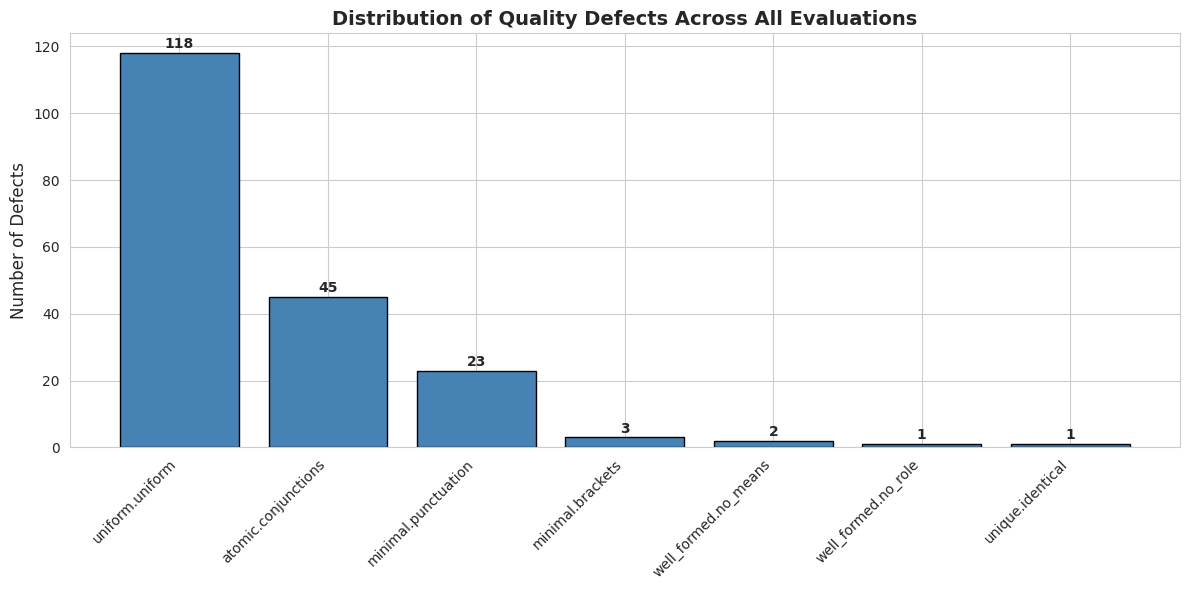

In [18]:
# Visualize defect distribution
defect_types = [d[0] for d in sorted_defects]
defect_counts = [d[1] for d in sorted_defects]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(defect_types)), defect_counts, color='steelblue', edgecolor='black')

# Add value labels
for i, (bar, count) in enumerate(zip(bars, defect_counts)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{count}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(range(len(defect_types)), defect_types, rotation=45, ha='right')
plt.ylabel('Number of Defects', fontsize=12)
plt.title('Distribution of Quality Defects Across All Evaluations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Model Comparison

In [19]:
# Compare models
model_stats = {}

for model in df['model'].unique():
    model_df = df[df['model'] == model]
    
    total_defects = 0
    total_stories = 0
    defect_types = defaultdict(int)
    
    for idx, row in model_df.iterrows():
        response = json.loads(row['response'])
        total_defects += response['summary']['total_defects']
        total_stories += response['summary']['total_stories']
        
        for defect_type, count in response['summary']['defect_types_count'].items():
            defect_types[defect_type] += count
    
    model_stats[model] = {
        'total_defects': total_defects,
        'total_stories': total_stories,
        'defect_rate': total_defects / total_stories,
        'avg_time': model_df['time'].mean(),
        'defect_types': dict(defect_types)
    }

# Display comparison
print("Model Comparison:\n")
for model, stats in model_stats.items():
    print(f"{model}:")
    print(f"  Stories analyzed: {stats['total_stories']}")
    print(f"  Total defects: {stats['total_defects']}")
    print(f"  Defect rate: {stats['defect_rate']:.2f} defects/story")
    print(f"  Avg processing time: {stats['avg_time']:.2f}s")
    print()

Model Comparison:

gpt-5-mini:
  Stories analyzed: 182
  Total defects: 47
  Defect rate: 0.26 defects/story
  Avg processing time: 109.07s

gpt-4:
  Stories analyzed: 183
  Total defects: 11
  Defect rate: 0.06 defects/story
  Avg processing time: 15.47s

gpt-5:
  Stories analyzed: 182
  Total defects: 135
  Defect rate: 0.74 defects/story
  Avg processing time: 236.24s



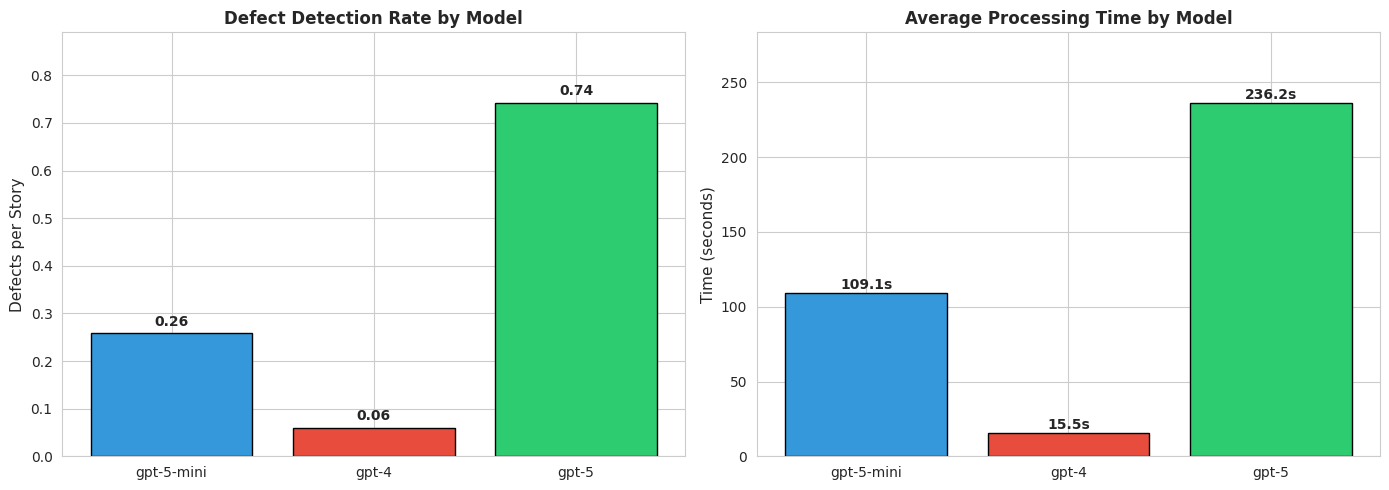

In [20]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Defect rate comparison
models = list(model_stats.keys())
defect_rates = [model_stats[m]['defect_rate'] for m in models]

axes[0].bar(models, defect_rates, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_ylabel('Defects per Story', fontsize=11)
axes[0].set_title('Defect Detection Rate by Model', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(defect_rates) * 1.2)

for i, rate in enumerate(defect_rates):
    axes[0].text(i, rate + 0.01, f'{rate:.2f}', ha='center', va='bottom', fontweight='bold')

# Processing time comparison
avg_times = [model_stats[m]['avg_time'] for m in models]

axes[1].bar(models, avg_times, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_ylabel('Time (seconds)', fontsize=11)
axes[1].set_title('Average Processing Time by Model', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, max(avg_times) * 1.2)

for i, time in enumerate(avg_times):
    axes[1].text(i, time + 0.5, f'{time:.1f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Performance Metrics

In [21]:
# Calculate performance metrics
print("Performance Summary:\n")
print(f"Total API calls: {len(df)}")
print(f"Total processing time: {df['time'].sum():.2f}s")
print(f"Average time per call: {df['time'].mean():.2f}s")
print(f"Min time: {df['time'].min():.2f}s")
print(f"Max time: {df['time'].max():.2f}s")
print(f"Std deviation: {df['time'].std():.2f}s")

Performance Summary:

Total API calls: 9
Total processing time: 1082.36s
Average time per call: 120.26s
Min time: 11.56s
Max time: 295.68s
Std deviation: 104.30s


## 5. Detailed Defect Analysis

Syntactic defects: 74 (54.8%)
Pragmatic defects: 119 (88.1%)


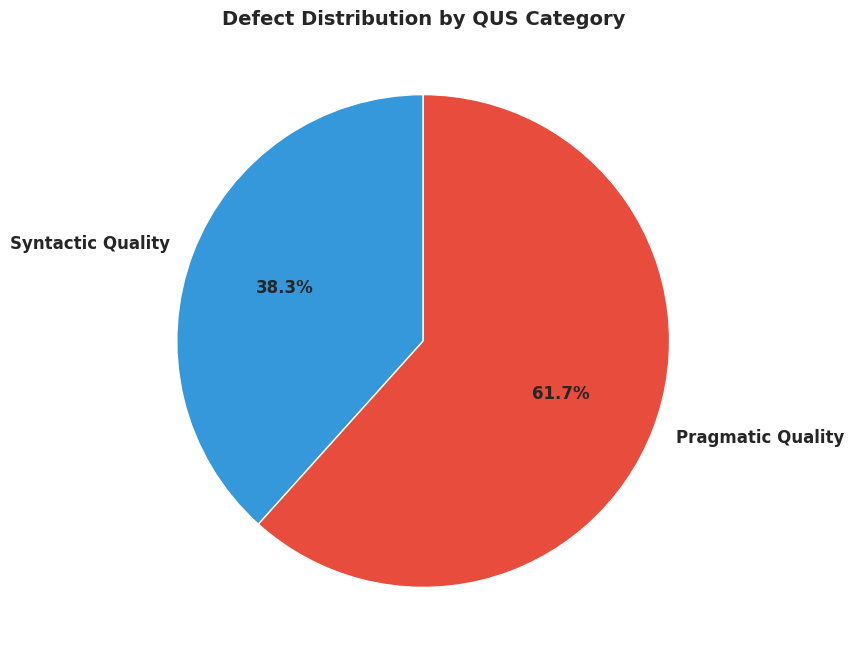

In [22]:
# Analyze defects by category
syntactic_defects = ['well_formed.no_role', 'well_formed.no_means', 'atomic.conjunctions', 
                     'minimal.punctuation', 'minimal.brackets']
pragmatic_defects = ['unique.identical', 'uniform.uniform']

syntactic_count = sum(all_defects[d] for d in syntactic_defects if d in all_defects)
pragmatic_count = sum(all_defects[d] for d in pragmatic_defects if d in all_defects)

print(f"Syntactic defects: {syntactic_count} ({syntactic_count/total_defects*100:.1f}%)")
print(f"Pragmatic defects: {pragmatic_count} ({pragmatic_count/total_defects*100:.1f}%)")

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie([syntactic_count, pragmatic_count], 
        labels=['Syntactic Quality', 'Pragmatic Quality'],
        autopct='%1.1f%%',
        colors=['#3498db', '#e74c3c'],
        startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Defect Distribution by QUS Category', fontsize=14, fontweight='bold')
plt.show()

## 6. Export Summary Statistics

In [23]:
# Create summary dataframe
summary_data = []

for model, stats in model_stats.items():
    summary_data.append({
        'Model': model,
        'Total Stories': stats['total_stories'],
        'Total Defects': stats['total_defects'],
        'Defect Rate': f"{stats['defect_rate']:.2f}",
        'Avg Time (s)': f"{stats['avg_time']:.2f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\nSummary Table:")
print(summary_df.to_string(index=False))

# Save to CSV
summary_df.to_csv('../data/processed/summary_statistics.csv', index=False)
print("\n✓ Summary saved to: data/processed/summary_statistics.csv")


Summary Table:
     Model  Total Stories  Total Defects Defect Rate Avg Time (s)
gpt-5-mini            182             47        0.26       109.07
     gpt-4            183             11        0.06        15.47
     gpt-5            182            135        0.74       236.24

✓ Summary saved to: data/processed/summary_statistics.csv
